Part 1:数据导入 + 初步探索

Dataset URL: https://www.kaggle.com/datasets/sc231997/crude-oil-price
License(s): CC0-1.0
Index(['date', 'price', 'percentChange', 'change'], dtype='object')


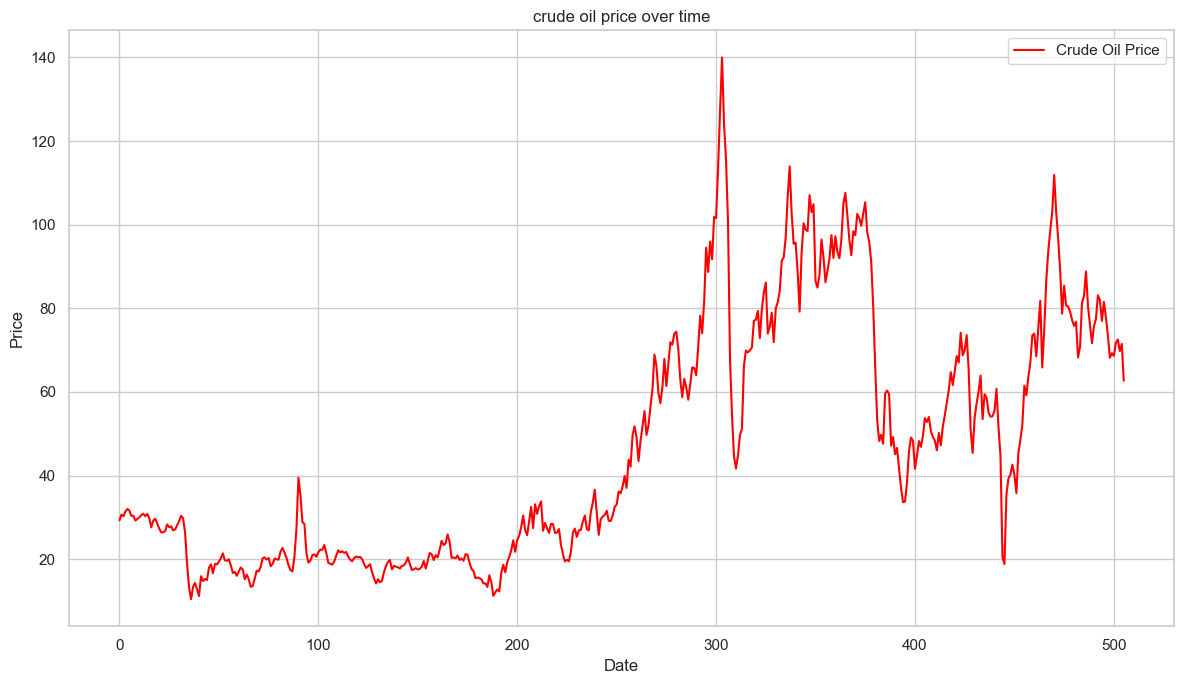

In [436]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

!kaggle datasets download -d sc231997/crude-oil-price --unzip #连接kaggle数据库
df = pd.read_csv('crude-oil-price.csv')
print(df.columns)
df.head(5)
df.fillna(0)
 
df['date']= pd.to_datetime(df['date'])
df['date'].index = range(1, len(time_series) + 1)
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(12,7))
plt.plot(df['price'], label='Crude Oil Price', color='red')
plt.title('crude oil price over time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Part 2: 特征工程

Index(['date', 'price', 'percentChange', 'change', 'lag_1', 'lag_2', 'lag_3',
       'lag_4', 'lag_5', 'lag_6', 'lag_7', 'price_last_year', 'year_change',
       'rolling_mean_quarterly', 'rolling_std_quarterly', 'returns',
       'log_return', 'normalized_return'],
      dtype='object')


<Axes: >

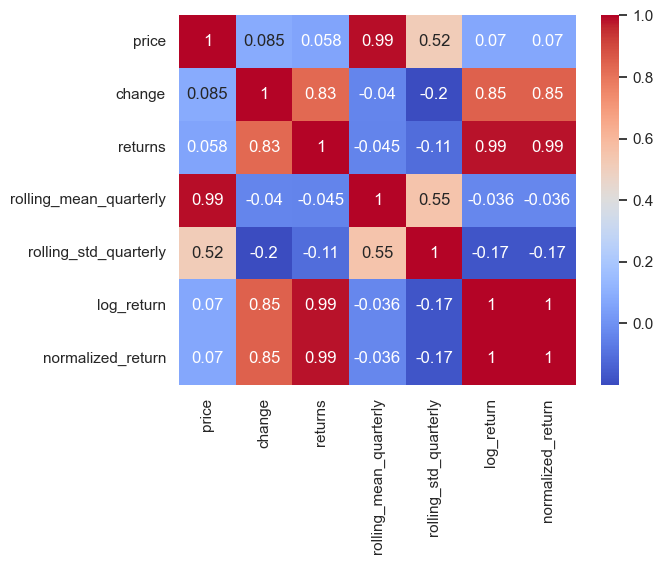

In [437]:
date_time = df['date'].dt.date
year_time = df['date'].dt.year
month_time = df['date'].dt.month
week_time = df['date'].dt.dayofweek

for i in range(1,8):
    df[f'lag_{i}'] = df['price'].shift(i)
    #print(df[f'lag_{i}'])

df['price_last_year'] = df['price'].shift(12)
df['year_change'] = df['price'] / df['price_last_year'] - 1

df['rolling_mean_quarterly'] = df['price'].rolling(3).mean()
df['rolling_std_quarterly'] = df['price'].rolling(3).std()
#print(df['rolling_mean_quarterly'])
#print(df['rolling_std_quarterly'])

change = df['price'].diff()
#print(change)
df['returns']= df['price'].pct_change() #用pandas求出简单收益率
#print(df['returns'])

close_prices = df['price'].values
close_prices = close_prices.flatten()
log_return = np.log(df['price'] / df['price'].shift(1))
df['log_return'] = (np.log(df['price'] / df['price'].shift(1))) * 100
df['normalized_return'] = (df['log_return'] - df['log_return'].mean()) / df['log_return'].std()

print(df.columns)
sns.heatmap(df[['price','change' ,'returns' ,'rolling_mean_quarterly','rolling_std_quarterly', 'log_return', 'normalized_return']].corr(), annot=True, cmap='coolwarm')

Part 3: 建模+比较

In [438]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_percentage_error

features = ['rolling_std_quarterly', 'change', 'normalized_return', 'rolling_mean_quarterly']
x = df[features].dropna()
y = df.loc[x.index, 'price']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [439]:
#1. 线性回归模型
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_percentage_error(y_test, y_pred_lr)
corr_lr = np.corrcoef(y_test, y_pred_lr)[0, 1]
print('\n线性回归R^2:',r2_lr )


线性回归R^2: 0.9972275794977113


In [440]:
#2. 随机森林回归模型
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
corr_rf = np.corrcoef(y_test, y_pred_rf)[0, 1]
print('\n 随机森林模型 R^2:', r2_rf)


 随机森林模型 R^2: 0.9847221284283184


In [441]:
#3. 多项式回归模型

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)
r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_percentage_error(y_test, y_pred_poly)
rmse_poly = root_mean_squared_error(y_test, y_pred_poly)
corr_poly = np.corrcoef(y_test, y_pred_poly)[0, 1]
print('多项式回归 R^2:', r2_poly)


多项式回归 R^2: 0.9171112381389944


In [442]:
df_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted_LR': y_pred_lr,
    'Predicted_RF': y_pred_rf,
    'Predicted_Poly': y_pred_poly
})

df_results.index = range(1, len(df_results) + 1)

print(df_results.tail(5))

     Actual  Predicted_LR  Predicted_RF  Predicted_Poly
148   51.56     49.118880     48.975811       51.491015
149   27.63     27.212176     27.404300       26.979483
150   21.74     21.974321     21.795400       22.041411
151   53.50     51.419139     55.953470       53.149694
152   40.27     39.041641     37.983300       39.035143


Part 4：评估模型效果

In [443]:
r2_rating = [r2_lr, r2_rf, r2_poly]
mae_rating = [mae_lr, mae_rf, mae_poly]
rmse_rating = [rmse_lr, rmse_rf, rmse_poly]
corr = [corr_lr, corr_rf, corr_poly]
score = pd.DataFrame({
    'model': ['LinearRegression', 'RandomForest', 'PolynomialRegressor'],
    'R2 score': [r2_lr, r2_rf, r2_poly],
    'MAE': [mae_lr, mae_rf, mae_poly],
    'RMSE': [rmse_lr, rmse_rf, rmse_poly],
    'Correlation': [corr_lr, corr_rf, corr_poly]})

score = score.sort_values(by='R2 score', ascending=False)
score.index = range(1, len(score)+1)
score

,model,R2 score,MAE,RMSE,Correlation
1,LinearRegression,0.997228,0.023466,1.488890,0.998623
2,RandomForest,0.984722,0.045842,3.495139,0.992397
3,PolynomialRegressor,0.917111,0.050766,8.141057,0.963407


<Axes: >

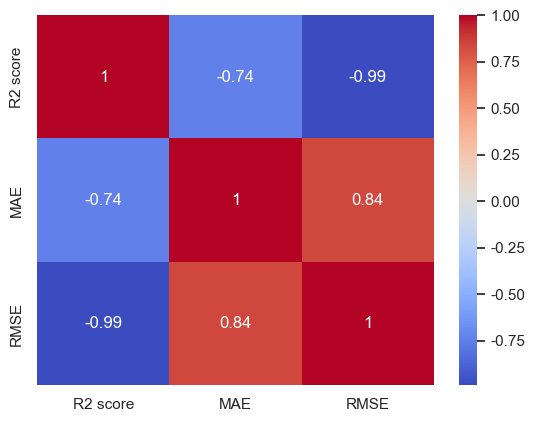

In [447]:
sns.heatmap(score[['R2 score', 'MAE', 'RMSE']].corr(), annot=True, cmap='coolwarm')

<Axes: xlabel='model', ylabel='RMSE'>

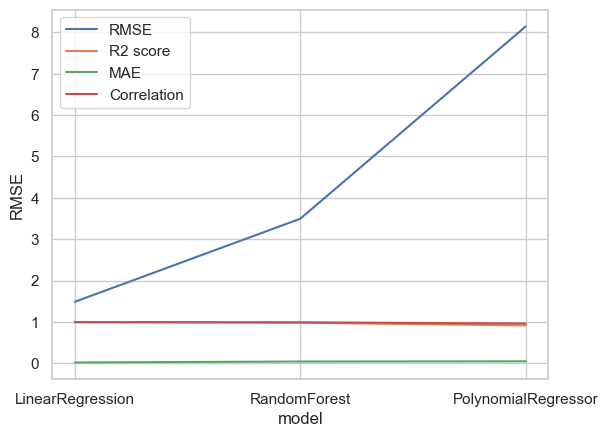

In [448]:
sns.set_theme(style='whitegrid')
sns.lineplot(data=score, x='model', y='RMSE', label='RMSE')
sns.lineplot(data=score, x='model', y='R2 score', label='R2 score')
sns.lineplot(data=score, x='model', y='MAE', label='MAE')
sns.lineplot(data=score, x='model', y='Correlation', label='Correlation')

Part 5: 总结模型表现 + 可视化趋势图或误差图

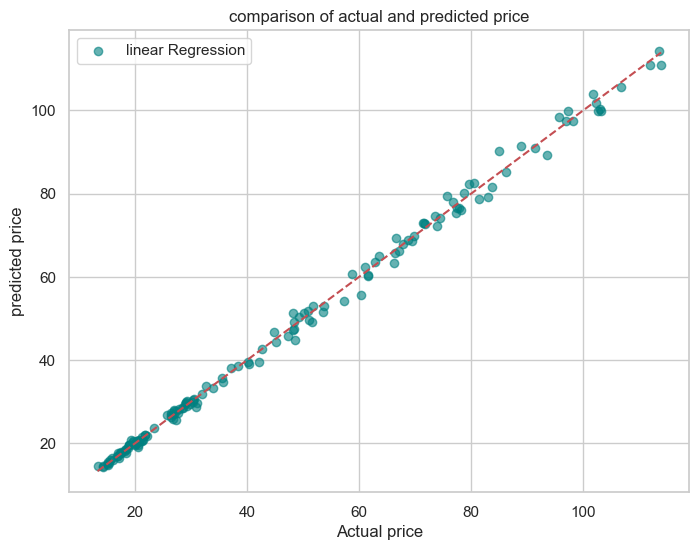

In [432]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, label='linear Regression', color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  
plt.xlabel("Actual price")
plt.ylabel("predicted price")
plt.title('comparison of actual and predicted price')
plt.legend()
plt.grid(True)
plt.show()

#模型评估结论总结

- 线性回归在本次实验中取得了最高的 R² 和最小的 RMSE、MAE---因此可以得出最佳模型为：线性回归模型
- Random Forest 表现也不错，稳定性高；多项式回归模型表现最差
- 当然我选择的三种模型是我用的最多的模型（也是最简单），也可以进一步对比更多类型的回归模型（KNN，Decision Tree, Ridge or Losso.

part 6:用得到的最佳模型，尝试预测未来原油价格

In [435]:
latest_price = df.iloc[-1:]
lastest_x = latest_price[features]
lastest_x_scaled = scaler.transform(lastest_x)
future_price = lr.predict(lastest_x_scaled)
future_price

array([61.57687956])